In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [94]:
from pydantic import BaseModel
from typing import Optional, Dict, Any, List, Literal


class Duration(BaseModel):
    min_days: int
    max_days: int


class DateRange(BaseModel):
    start: str
    end: str


class StructuredTravel(BaseModel):
    currentLocation: str
    destination: str
    duration: Duration
    date_range: DateRange
    budget: Optional[Literal["low", "medium", "high"]] = None
    travel_style: Optional[Literal["solo", "couple", "family"]] = None
    preferences: List[str] = []


class DayPlan(BaseModel):
    day: int
    location: str
    plan: List[str]


class ItineraryOutput(BaseModel):
    summary: str
    days: List[DayPlan]


class CritiqueOutput(BaseModel):
    status: Literal["approved", "revise", "infeasible"]
    issues: List[str] = []
    suggestions: List[str] = []


class TravelState(BaseModel):
    query: str

    structured: Optional[Dict[str, Any]] = None
    itinerary: Optional[Dict[str, Any]] = None
    critique: Optional[Dict[str, Any]] = None

In [95]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [ ]:
import json


parser_llm = llm.with_structured_output(StructuredTravel)
planner_llm = llm.with_structured_output(ItineraryOutput)
critic_llm = llm.with_structured_output(CritiqueOutput)


def parserNode(state: TravelState):
    prompt = f"""
Extract structured travel data from this query:
{state.query}
"""

    structured_obj = parser_llm.invoke(prompt)
    structured = structured_obj.model_dump()
    print("structured", structured)

    return {"structured": structured}



In [97]:
def plannerNode(state: TravelState):
    structured = state.structured or {"query": state.query}
    print("planner input", structured)

    prompt = f"""
Create a travel itinerary based on this structured input:
{json.dumps(structured)}

Requirements:
- Use ONLY the destination from input.
- Match number of days to duration/date range.
"""

    itinerary_obj = planner_llm.invoke(prompt)
    itinerary = itinerary_obj.model_dump()
    print("itinerary", itinerary)

    return {"itinerary": itinerary}

In [98]:
def critic_node(state: TravelState):
    print("critic itinerary", state.itinerary)

    prompt = f"""
You are a strict travel validator.

Check:
1. Is trip feasible (distance vs duration)?
2. Travel time realistic?
3. Matches preferences?

INPUT:
Structured: {json.dumps(state.structured or {})}
Itinerary: {json.dumps(state.itinerary or {})}
"""

    critique_obj = critic_llm.invoke(prompt)
    critique = critique_obj.model_dump()

    print("critique", critique)
    return {"critique": critique}

In [99]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(TravelState)

graph.add_node("parser",parserNode)
graph.add_node("planner",plannerNode)
graph.add_node("critic",critic_node)

graph.add_edge(START,"parser")
graph.add_edge("parser","planner")
graph.add_edge("planner","critic")
graph.add_edge("critic",END)

graph = graph.compile()

In [100]:
res = graph.invoke({"query":"plan the trip for malvan from mumbai from 1 may 2026 - 3 may 2026 in medium budget, it san romantic trip"})

structured {'currentLocation': 'mumbai', 'destination': 'malvan', 'duration': {'min_days': 3, 'max_days': 3}, 'date_range': {'start': '1 may 2026', 'end': '3 may 2026'}, 'budget': 'medium', 'travel_style': 'couple', 'preferences': []}
planner input {'currentLocation': 'mumbai', 'destination': 'malvan', 'duration': {'min_days': 3, 'max_days': 3}, 'date_range': {'start': '1 may 2026', 'end': '3 may 2026'}, 'budget': 'medium', 'travel_style': 'couple', 'preferences': []}
itinerary {'summary': 'A delightful 3-day romantic getaway to Malvan, exploring its pristine beaches, historic fort, and indulging in local Malvani cuisine and water sports.', 'days': [{'day': 1, 'location': 'Malvan', 'plan': ['Arrive in Malvan and check into your accommodation.', 'Enjoy a traditional Malvani seafood lunch.', 'Relax and unwind at Tarkarli Beach or Chivla Beach.', 'Witness a beautiful sunset over the Arabian Sea.', 'Savor local delicacies for dinner at a beachfront restaurant.']}, {'day': 2, 'location': 'M

In [104]:
res["critique"]

{'status': 'revise',
 'issues': ['The 3-day duration is extremely tight for the ~500-550 km distance from Mumbai to Malvan, allowing for only approximately 1.5 effective days of exploration after accounting for travel time.',
  'The Day 1 itinerary suggesting arrival and a traditional Malvani seafood lunch is unrealistic. A 9-12 hour journey from Mumbai means arrival would be in the late afternoon or evening, making a leisurely lunch upon arrival improbable.',
  "The extensive travel time packed into a short 3-day window is likely to lead to exhaustion rather than a 'delightful romantic getaway'."],
 'suggestions': ['Consider extending the trip to at least 4-5 days to allow for more relaxed travel and sufficient time to enjoy Malvan without feeling rushed.',
  'If a 3-day duration is fixed, revise the Day 1 itinerary to realistically account for the full day of travel. Expect arrival in the late afternoon/evening, with dinner as the primary activity upon reaching Malvan.',
  'Manage ex

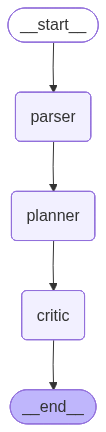

In [91]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())